In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import importlib, os
import east

In [2]:
importlib.reload(east)

key    = jax.random.PRNGKey(42)
N      = 512
n_runs = 30

ls = [3, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]  # characteristic lengths; T = 1/ln(l-1), c_eq = 1/l

# max_t targeted at ~2 tau for each l
# measured tau: ~10, 35, 266, 1343, 4461, 15123, 42807, 102629, 241763, ~535000, ~1130000
window = {
    3:  dict(dt_record=0.1,      n_records=150),  # max_t=15
    4:  dict(dt_record=0.5,      n_records=200),  # max_t=100
    6:  dict(dt_record=4.0,      n_records=150),  # max_t=600
    8:  dict(dt_record=25.0,     n_records=150),  # max_t=3750
    10: dict(dt_record=120.0,    n_records=120),  # max_t=14400
    12: dict(dt_record=600.0,    n_records=80),   # max_t=48000
    14: dict(dt_record=3000.0,   n_records=45),   # max_t=135000
    16: dict(dt_record=8000.0,   n_records=30),   # max_t=240000
    18: dict(dt_record=25000.0,  n_records=25),   # max_t=625000
    20: dict(dt_record=55000.0,  n_records=25),   # max_t=1375000
    22: dict(dt_record=160000.0, n_records=20),   # max_t=3200000
}

if os.path.exists("acf_results.npy"):
    results = np.load("acf_results.npy", allow_pickle=True).item()
    print("Loaded results from acf_results.npy")
    for l in ls:
        r = results[l]
        print(f"l={l:2d}  T={r['T']:.4f}  tau={r['tau']:12.1f} ± {r['tau_err']:.1f}  max_t={r['times'][-1]:.1f}")
else:
    results = {}
    for l in ls:
        T = float(east.temperature_from_length(l))
        p = window[l]
        key, subkey = jax.random.split(key)
        times, C, C_err, tau, tau_err = east.ensemble_autocorrelation(
            N, T, p['dt_record'], p['n_records'], n_runs, subkey
        )
        results[l] = dict(T=T, times=np.array(times), C=np.array(C), C_err=np.array(C_err),
                          tau=float(tau), tau_err=float(tau_err))
        print(f"l={l:2d}  T={T:.4f}  tau={float(tau):12.1f} ± {float(tau_err):.1f}  max_t={float(times[-1]):.1f}")

Loaded results from acf_results.npy
l= 3  T=1.4427  tau=        10.7 ± nan  max_t=15.0
l= 4  T=0.9102  tau=        44.9 ± 1.7  max_t=100.0
l= 6  T=0.6213  tau=       332.4 ± 15.5  max_t=600.0
l= 8  T=0.5139  tau=      1524.8 ± 72.5  max_t=3750.0
l=10  T=0.4551  tau=      6781.1 ± nan  max_t=14400.0
l=12  T=0.4170  tau=     15659.2 ± 1132.4  max_t=48000.0
l=14  T=0.3899  tau=     52757.4 ± 4692.3  max_t=135000.0
l=16  T=0.3693  tau=    131243.2 ± nan  max_t=240000.0
l=18  T=0.3530  tau=    491231.8 ± nan  max_t=625000.0
l=20  T=0.3396  tau=   1363277.1 ± nan  max_t=1375000.0
l=22  T=0.3285  tau=   2742916.5 ± nan  max_t=3200000.0


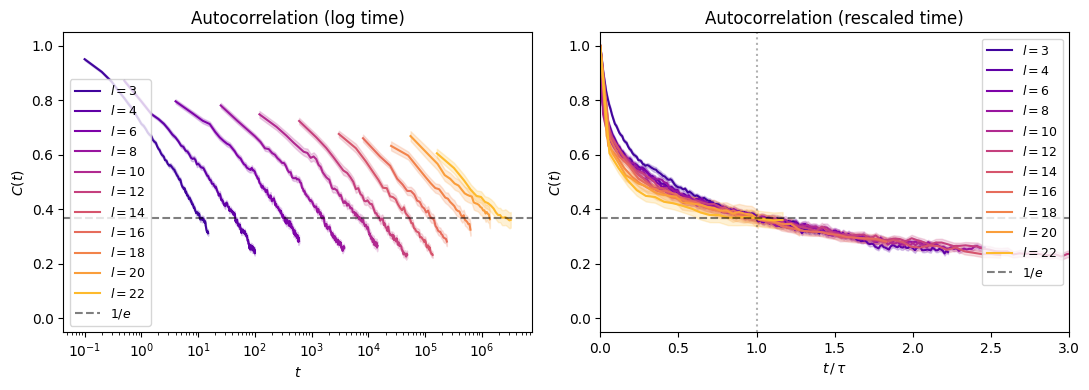

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(ls)))

# Left: raw log-time — slowing down is immediately obvious
ax = axes[0]
for l, color in zip(ls, colors):
    r = results[l]
    mask = r['times'] > 0
    ax.semilogx(r['times'][mask], r['C'][mask], color=color, label=f'$l={l}$')
    ax.fill_between(r['times'][mask],
                    (r['C'] - r['C_err'])[mask],
                    (r['C'] + r['C_err'])[mask],
                    alpha=0.2, color=color)
ax.axhline(1/np.e, color='k', ls='--', alpha=0.5, label='$1/e$')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$C(t)$')
ax.set_title('Autocorrelation (log time)')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

# Right: time rescaled by measured tau (tau = crossing of mean C, so crosshair is exact)
# skip any l whose mean C didn't reach 1/e within the recorded window
ax = axes[1]
for l, color in zip(ls, colors):
    r = results[l]
    if np.isnan(r['tau']):
        continue
    t_sc = r['times'] / r['tau']
    ax.plot(t_sc, r['C'], color=color, label=f'$l={l}$')
    ax.fill_between(t_sc,
                    r['C'] - r['C_err'],
                    r['C'] + r['C_err'],
                    alpha=0.2, color=color)
ax.axhline(1/np.e, color='k', ls='--', alpha=0.5, label='$1/e$')
ax.axvline(1.0,    color='k', ls=':',  alpha=0.3)
ax.set_xlabel(r'$t\,/\,\tau$')
ax.set_ylabel(r'$C(t)$')
ax.set_title('Autocorrelation (rescaled time)')
ax.set_xlim(0, 3)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

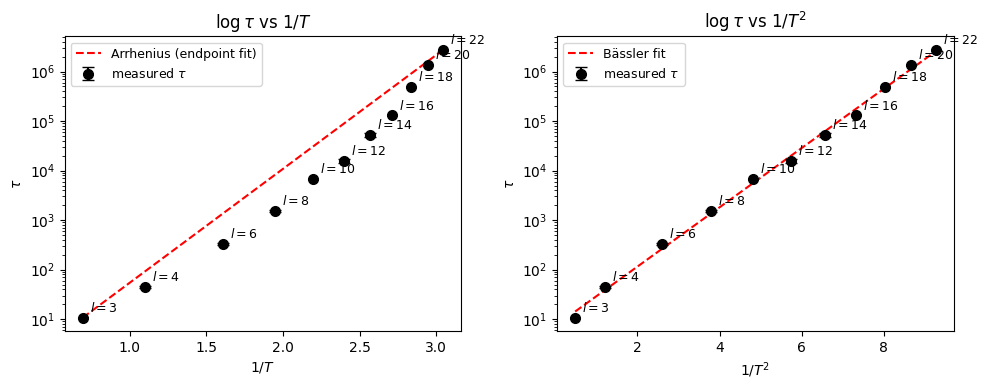

In [5]:
T_arr       = np.array([results[l]['T']       for l in ls])
tau_arr     = np.array([results[l]['tau']     for l in ls])
tau_err_arr = np.array([results[l]['tau_err'] for l in ls])
invT        = 1.0 / T_arr
invT2       = invT ** 2
log_tau     = np.log(tau_arr)

# exclude any l whose mean C didn't reach 1/e within the recorded window
valid = ~np.isnan(tau_arr) # & (np.array(ls) > 4)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, xvals, xlabel, title, fit_label, two_point in [
    (axes[0], invT,  r'$1/T$',   r'$\log\tau$ vs $1/T$',   'Arrhenius (endpoint fit)', True),
    (axes[1], invT2, r'$1/T^2$', r'$\log\tau$ vs $1/T^2$', 'Bässler fit',              False),
]:
    ax.errorbar(xvals[valid], tau_arr[valid], yerr=tau_err_arr[valid],
                color='black', fmt='o', ms=7, capsize=4, zorder=3, label=r'measured $\tau$')
    for l, x, tau in zip(np.array(ls)[valid], xvals[valid], tau_arr[valid]):
        ax.annotate(f'$l={l}$', (x, tau), textcoords='offset points',
                    xytext=(5, 4), fontsize=9)
    if two_point:
        x0, x1 = xvals[valid][0], xvals[valid][-1]
        y0, y1 = log_tau[valid][0], log_tau[valid][-1]
        slope = (y1 - y0) / (x1 - x0)
        coeffs = np.array([slope, y0 - slope * x0])
    else:
        coeffs = np.polyfit(xvals[valid], log_tau[valid], 1)
    x_fit  = np.linspace(xvals[valid].min(), xvals[valid].max(), 200)
    ax.semilogy(x_fit, np.exp(np.polyval(coeffs, x_fit)), 'r--', lw=1.5, label=fit_label)
    ax.set_yscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$\tau$')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
if not os.path.exists("acf_results.npy"):
    np.save("acf_results.npy", results)